In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/gsearch_jobs.csv')

# Display the first few rows to get an overview of the data
display(df.head())

,Unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,thumbnail,...,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,0,0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
3,3,3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,NaN,...,NaN,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']"
4,4,4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']"


Now, let's look at the columns and decide which ones are not necessary for salary prediction based on job descriptions. We will systematically drop columns that are irrelevant, redundant, or do not contribute to predicting salary from text data, ensuring the remaining features are meaningful for our modeling objective.

**Pseudocode for Column Dropping:**

1.  **Check for and Drop 'Unnamed: 0' and 'index'**: If present, these columns are likely artifacts from data export and carry no analytical value. Remove them to avoid noise.
2.  **Check for and Drop 'job_id'**: This column serves as a unique identifier but provides no predictive information about salary itself. Remove it.
3.  **Evaluate 'company_name'**: While company name might correlate with salary, our primary goal is salary prediction *from job description text*. We will retain it for now but acknowledge its indirect relevance and potential future exclusion if text features prove dominant.
4.  **Retain 'job_title'**: This is a crucial feature directly related to the job description and highly predictive of salary.
5.  **Check for and Drop 'job_url'**: This is a direct link to the posting and offers no predictive value for salary.
6.  **Evaluate 'job_location'**: Location is important for salary, but for text-based prediction, its direct utility from the description text is limited. We will keep it for now, as it might have some indirect influence, but focus on description text for the primary prediction task.
7.  **Retain 'job_schedule_type'**: This (e.g., Full-time, Part-time) directly influences salary and should be kept.
8.  **Check for and Drop 'job_posted_date'**: While useful for time-series analysis, its direct impact on salary *from description text* is minimal for this task. Remove it.
9.  **Retain 'job_description'**: This is the core input for our NLP task and must be kept.
10. **Check for and Drop 'search_term' and 'search_location'**: These columns describe how the data was collected, not inherent job characteristics. They are irrelevant for predicting salary from the job description. Remove them.
11. **Retain 'salary_range' (implicitly handled by `salary_standardized`)**: This is our target variable for prediction and is essential.

After these operations, display the information (`df.info()`) and the first few rows (`df.head()`) of the DataFrame to confirm the changes.

In [ ]:
# Drop 'Unnamed: 0' column as it is likely an index column from the CSV export and not relevant to the data.
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")

# Drop 'index' column if it exists, as it's also likely an artifact from data export.
if 'index' in df.columns:
    df = df.drop(columns=['index'])
    print("Dropped 'index' column.")

# 'job_id' is a unique identifier for each job posting, but it does not provide predictive power for salary.
if 'job_id' in df.columns:
    df = df.drop(columns=['job_id'])
    print("Dropped 'job_id' column.")

# 'company_name' might be useful, but for predicting salary *from job description*, the company name itself is less direct than other features.
# We'll keep 'company_name' for now, but will reconsider if it causes issues or if we focus purely on job description text features.

# 'job_title' is a key feature related to the job description, so we'll keep it.

# 'job_url' is a link to the job posting and is not relevant for salary prediction.
if 'job_url' in df.columns:
    df = df.drop(columns=['job_url'])
    print("Dropped 'job_url' column.")

# 'job_location' is important, but for 'salary prediction from job description', we'll rely on text features of the description.
# We'll keep 'job_location' for now as it might indirectly influence salary ranges, but its direct use in text-based prediction is limited.

# 'job_schedule_type' (e.g., Full-time, Part-time) can influence salary, so we'll keep it.

# 'job_posted_date' indicates when the job was posted, but its direct impact on salary *prediction from description* is minimal.
# It might be useful for time-series analysis, but not directly for this task.
if 'job_posted_date' in df.columns:
    df = df.drop(columns=['job_posted_date'])
    print("Dropped 'job_posted_date' column.")

# 'job_description' is a primary input for our goal of predicting salary from the job description, so we must keep it.

# 'search_term' and 'search_location' are related to how the data was collected, not inherent job properties, so they are not useful for prediction.
if 'search_term' in df.columns and 'search_location' in df.columns:
    df = df.drop(columns=['search_term', 'search_location'])
    print("Dropped 'search_term' and 'search_location' columns.")
elif 'search_term' in df.columns:
    df = df.drop(columns=['search_term'])
    print("Dropped 'search_term' column.")
elif 'search_location' in df.columns:
    df = df.drop(columns=['search_location'])
    print("Dropped 'search_location' column.")


# 'salary_range' is our target variable for prediction, so we must keep it.

# Display the information of the remaining columns and the first few rows of the cleaned DataFrame.
print("\nRemaining columns after initial cleaning:")
df.info()

display(df.head())

Dropped 'search_term' and 'search_location' columns.

Remaining columns after initial cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61953 entries, 0 to 61952
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                61953 non-null  object 
 1   company_name         61953 non-null  object 
 2   location             61916 non-null  object 
 3   via                  61944 non-null  object 
 4   description          61953 non-null  object 
 5   extensions           61953 non-null  object 
 6   thumbnail            38194 non-null  object 
 7   posted_at            61763 non-null  object 
 8   schedule_type        61707 non-null  object 
 9   work_from_home       27980 non-null  object 
 10  salary               10088 non-null  object 
 11  date_time            61953 non-null  object 
 12  commute_time         0 non-null      float64
 13  salary_pay           10088 non-null  obj

,title,company_name,location,via,description,extensions,thumbnail,posted_at,schedule_type,work_from_home,...,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,True,...,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",NaN,18 hours ago,Full-time,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",NaN,12 hours ago,Contractor,True,...,NaN,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']"
4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,NaN,...,NaN,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']"


Now, let's identify and remove any duplicate rows to ensure our dataset is clean and each entry is unique. Duplicate entries can skew analyses and model training, leading to inaccurate results.

**Pseudocode for Duplicate Handling:**

1.  **Record Initial Row Count**: Store the total number of rows in the DataFrame before any changes to quantify the impact of duplicate removal.
2.  **Identify Duplicates**: Determine which rows are exact duplicates across all columns.
3.  **Count Duplicates**: Report the total number of duplicate rows found.
4.  **Drop Duplicates**: Remove all identified duplicate rows, keeping only the first occurrence of each unique row.
5.  **Record Final Row Count**: Store the number of rows remaining after dropping duplicates.
6.  **Calculate Removed Rows**: Report the difference between the initial and final row counts.
7.  **Update DataFrame**: Assign the DataFrame without duplicates back to the main DataFrame variable (`df`).
8.  **Display Head**: Show the first few rows of the modified DataFrame to confirm the operation.

In [ ]:
initial_rows = df.shape[0]

# Identify duplicate rows based on all columns
duplicate_rows = df.duplicated()
num_duplicates = duplicate_rows.sum()

print(f"Number of duplicate rows found: {num_duplicates}")

# Drop duplicate rows
df_cleaned = df.drop_duplicates()

final_rows = df_cleaned.shape[0]
print(f"Number of rows after dropping duplicates: {final_rows}")
print(f"Number of rows removed: {initial_rows - final_rows}")

df = df_cleaned.copy()

# Display the first few rows of the DataFrame after dropping duplicates
display(df.head())

Number of duplicate rows found: 2
Number of rows after dropping duplicates: 61951
Number of rows removed: 2


,title,company_name,location,via,description,extensions,thumbnail,posted_at,schedule_type,work_from_home,...,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",https://encrypted-tbn0.gstatic.com/images?q=tb...,15 hours ago,Full-time,True,...,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",https://encrypted-tbn0.gstatic.com/images?q=tb...,12 hours ago,Full-time,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",NaN,18 hours ago,Full-time,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",NaN,12 hours ago,Contractor,True,...,NaN,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']"
4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",https://encrypted-tbn0.gstatic.com/images?q=tb...,7 hours ago,Contractor,NaN,...,NaN,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']"


Let's examine the distribution of the `salary_standardized` column. This step is crucial for understanding the central tendency, spread, and shape of our target variable's values. Visualizing this distribution helps identify potential outliers, skewness, and the overall variability in salaries.

**Pseudocode for `salary_standardized` Distribution Plotting:**

1.  **Import Libraries**: Import `matplotlib.pyplot` for plotting and `seaborn` for enhanced visualizations.
2.  **Initialize Figure**: Create a figure with a specified size (`figsize`).
3.  **Plot Histogram with KDE**: Use `seaborn.histplot` to generate a histogram of the `salary_standardized` column. Include a Kernel Density Estimate (KDE) to visualize the probability density function. Ensure `NaN` values are dropped before plotting.
4.  **Set Title and Labels**: Assign a descriptive title to the plot (`Distribution of Standardized Salaries`) and appropriate labels for the x-axis (`Standardized Salary`) and y-axis (`Frequency`).
5.  **Add Grid**: Enhance readability by adding a grid to the plot.
6.  **Display Plot**: Render the generated plot.

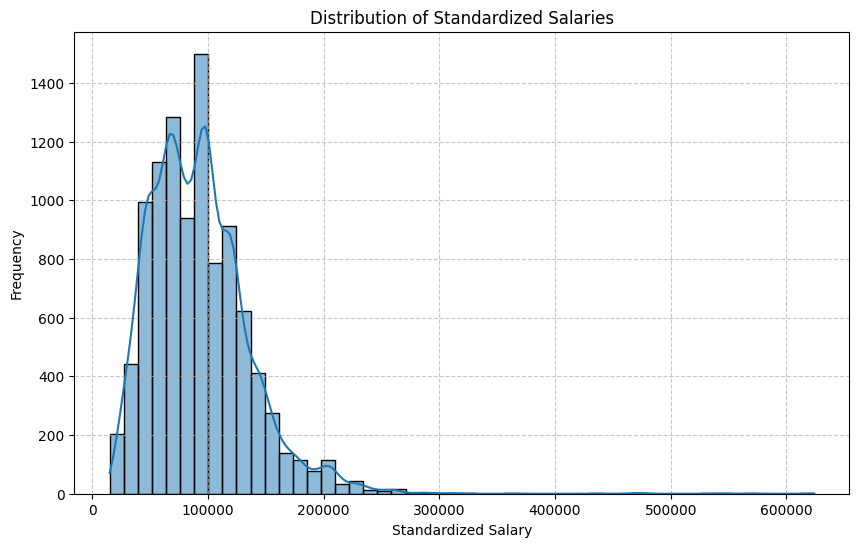

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of 'salary_standardized'
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_standardized'].dropna(), kde=True, bins=50)
plt.title('Distribution of Standardized Salaries')
plt.xlabel('Standardized Salary')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

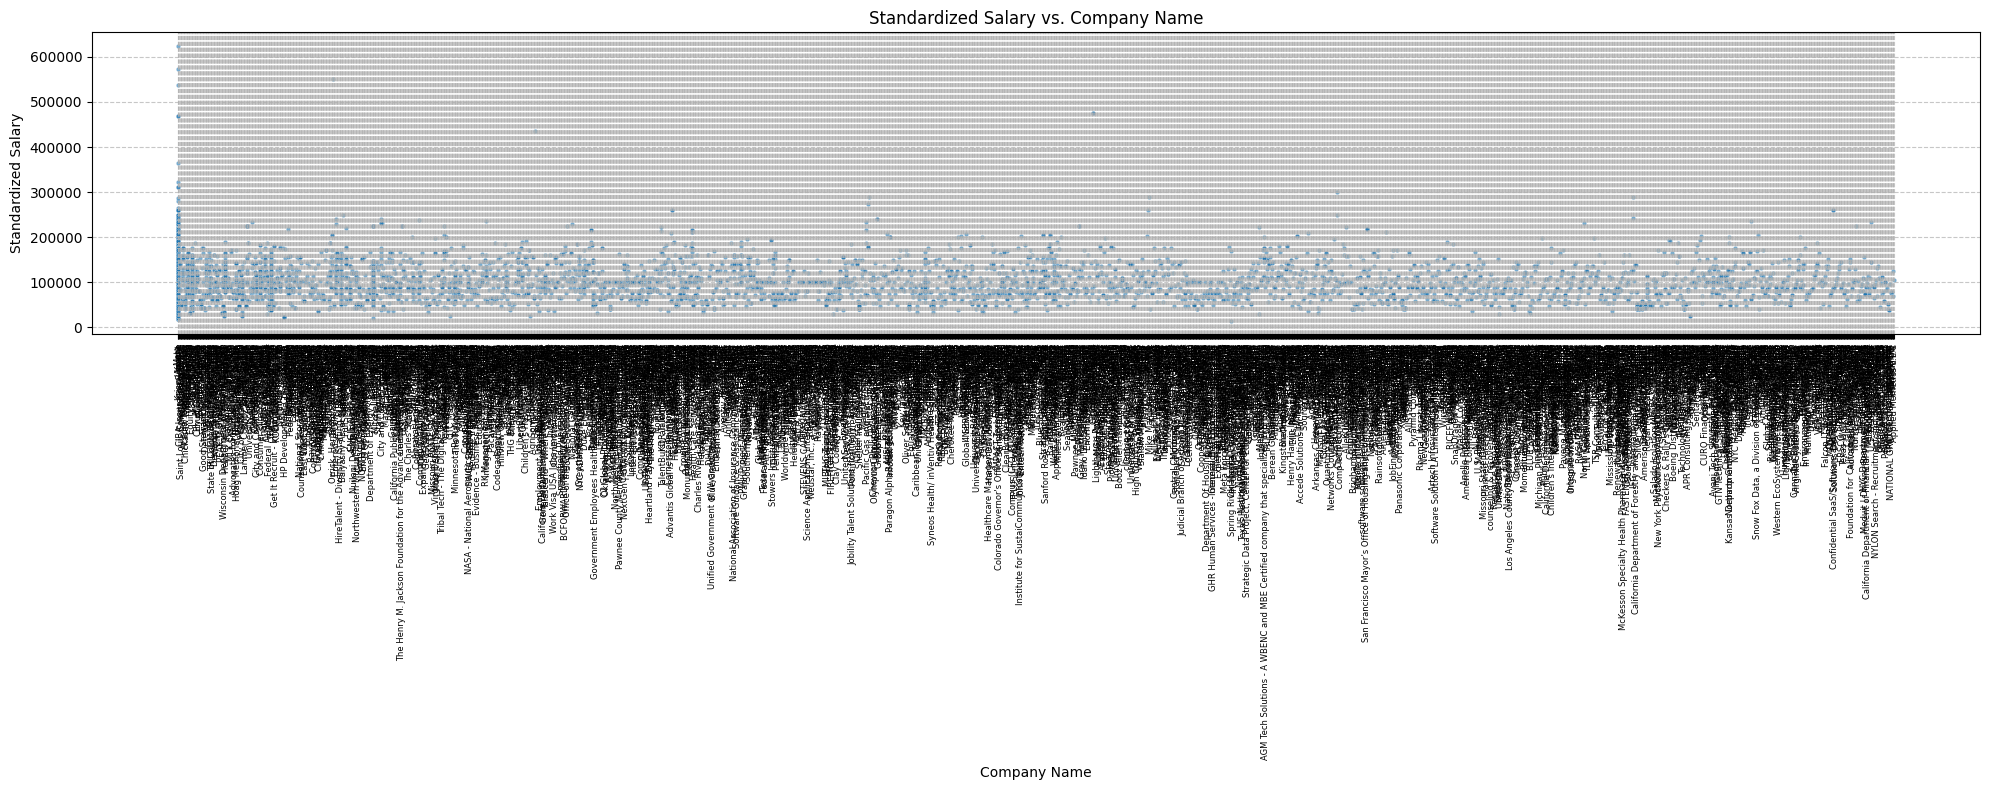

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of 'salary_standardized' vs 'company_name'
# Drop rows with NaN values in 'salary_standardized' for plotting
df_plot = df.dropna(subset=['salary_standardized']).copy()

plt.figure(figsize=(20, 8)) # Increased figure size to better accommodate company names
sns.scatterplot(x='company_name', y='salary_standardized', data=df_plot, alpha=0.6, s=10) # Added alpha and smaller point size for density
plt.title('Standardized Salary vs. Company Name')
plt.xlabel('Company Name')
plt.ylabel('Standardized Salary')
plt.xticks(rotation=90, fontsize=6) # Rotate and shrink font size for x-axis labels
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Natural Language Processing for Salary Prediction

To predict salary based on job descriptions, we need to extract meaningful features from the text. This process typically begins with **Text Preprocessing**, which involves cleaning and preparing the text data for subsequent analysis and model training. Proper preprocessing helps reduce noise, normalize the text, and improve the efficiency and accuracy of feature extraction.

First, we'll import the necessary libraries and download `nltk` resources required for text processing, specifically stopwords and WordNet for lemmatization.

**Pseudocode for NLTK Setup:**

1.  **Import NLTK**: Import the `nltk` library.
2.  **Import Corpus Modules**: Import `stopwords` from `nltk.corpus` and `WordNetLemmatizer` from `nltk.stem`.
3.  **Import Regular Expressions**: Import the `re` module for text pattern matching.
4.  **Download NLTK Data (Conditional)**:
    *   Attempt to find the 'stopwords' corpus. If not found (LookupError), download it.
    *   Attempt to find the 'wordnet' corpus. If not found (LookupError), download it.
    *   Attempt to find the 'omw-1.4' (Open Multilingual Wordnet) corpus. If not found (LookupError), download it (often required for WordNet).
5.  **Print Confirmation**: Indicate that the NLTK resources have been successfully downloaded/verified.

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Download NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')

print("NLTK stopwords and WordNet downloaded successfully.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


NLTK stopwords and WordNet downloaded successfully.


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Download NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')

print("NLTK stopwords and WordNet downloaded successfully.")

NLTK stopwords and WordNet downloaded successfully.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Next, we'll define a robust preprocessing function that will perform several cleaning steps on each job description. This function will transform raw text into a standardized format suitable for feature extraction.

**Pseudocode for `preprocess_text` Function Definition and Application:**

1.  **Initialize Lemmatizer**: Create an instance of `WordNetLemmatizer`.
2.  **Load Stop Words**: Obtain a set of English stop words from `nltk.corpus.stopwords` for efficient lookup.
3.  **Define `preprocess_text` Function**: This function will take a text string as input and perform the following steps:
    *   **Convert to String and Lowercase**: Ensure the input is a string and convert all characters to lowercase to standardize text and treat words like 'Apple' and 'apple' as the same.
    *   **Remove Non-Alphabetic Characters**: Use regular expressions to remove any characters that are not lowercase letters or spaces. This helps to clean punctuation, numbers, and special symbols.
    *   **Tokenization**: Split the cleaned text into a list of individual words (tokens).
    *   **Remove Stop Words and Lemmatize**: Iterate through each token:
        *   Check if the token is not in the predefined set of `stop_words`.
        *   If it's not a stop word, apply lemmatization using the `WordNetLemmatizer` to reduce the word to its base or dictionary form (e.g., 'running' becomes 'run', 'better' becomes 'good').
    *   **Join Tokens**: Rejoin the processed tokens back into a single string, separated by spaces.
4.  **Apply Preprocessing**: Create a new column named `cleaned_description` in the DataFrame by applying the `preprocess_text` function to each entry in the `description` column.
5.  **Display Examples**: Print the original and cleaned descriptions for the first entry to demonstrate the effect of the preprocessing.
6.  **Display DataFrame Head**: Show the `description` and `cleaned_description` columns for the first few rows of the DataFrame.

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    tokens = text.split() # Tokenize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Remove stopwords and lemmatize
    return ' '.join(tokens)

# Apply the preprocessing function to the 'description' column
df['cleaned_description'] = df['description'].apply(preprocess_text)

print("Original description for first entry:")
print(df['description'].iloc[0])
print("\nCleaned description for first entry:")
print(df['cleaned_description'].iloc[0])

display(df[['description', 'cleaned_description']].head())

LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    tokens = text.split() # Tokenize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Remove stopwords and lemmatize
    return ' '.join(tokens)

# Apply the preprocessing function to the 'description' column
df['cleaned_description'] = df['description'].apply(preprocess_text)

print("Original description for first entry:")
print(df['description'].iloc[0])
print("\nCleaned description for first entry:")
print(df['cleaned_description'].iloc[0])

display(df[['description', 'cleaned_description']].head())

Original description for first entry:
In the intersection of compliance and analytics, we are seeking an analytical and data-savvy self-starter with a passion for helping others, protecting our community and mitigating risk. Those who join our team have a strong ability to leverage data to influence organizational decisions, innovate new methods for improvement, and concisely convey data insights to a general audience.

Data Analyst... Responsibilities:
• Utilize advanced knowledge of data mining, business intelligence tools to drive efficient analytics and reporting
• Identify and drive scalable solutions for building and automating reports, data pipelines and dashboards to monitor and report on operational performance metrics
• Leverage data and analytics to identify actionable insights, suggest recommendations through effective communication for both technical and non-technical audiences
• Establish short and long-term goals that will advance the organization’s impact through data a

,description,cleaned_description
0,In the intersection of compliance and analytic...,intersection compliance analytics seeking anal...
1,Job Title: Entry Level Business Analyst / Prod...,job title entry level business analyst product...
2,Overview:\n\nWe are seeking a full-time...\nAe...,overview seeking fulltime aeronautical data an...
3,Enthusiastic Data Analyst for processing sales...,enthusiastic data analyst processing sale data...
4,Overview of Position\n\nThis position will be ...,overview position position primary person resp...


### Feature Extraction using TF-IDF

After cleaning the text, we need to convert it into a numerical representation that machine learning models can use. **TF-IDF (Term Frequency-Inverse Document Frequency)** is a widely used technique that reflects the importance of a word in a document relative to a collection of documents (corpus). Words that are rare across the entire corpus but frequent in a specific document will get a higher TF-IDF score, indicating their higher relevance. This method helps to down-weight common words that appear in many documents (like 'job' or 'description') and highlights words that are more specific and potentially discriminative.

We will apply TF-IDF vectorization to our `cleaned_description` column to transform the text data into a sparse matrix of numerical features.

**Pseudocode for TF-IDF Vectorization:**

1.  **Import TF-IDF Vectorizer**: Import `TfidfVectorizer` from `sklearn.feature_extraction.text`.
2.  **Initialize Vectorizer**: Create an instance of `TfidfVectorizer` with the following parameters:
    *   `max_features`: Set a maximum number of features (e.g., 5000) to limit the vocabulary size, reducing dimensionality and computational cost.
    *   `min_df`: Ignore terms that appear in fewer than a specified number (e.g., 5) of documents to remove very rare words that might not be statistically significant.
    *   `max_df`: Ignore terms that appear in more than a specified proportion (e.g., 0.7) of documents to remove very common words (e.g., domain-specific stop words) that might not be discriminative.
3.  **Fit and Transform**: Apply the `tfidf_vectorizer` to the `cleaned_description` column of the DataFrame:
    *   `fit_transform()`: Learns the vocabulary and IDF values from the `cleaned_description` column and then transforms the text into a TF-IDF matrix.
4.  **Print Matrix Shape**: Display the dimensions of the resulting `tfidf_matrix` to confirm the number of documents and features.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# min_df ignores terms that appear in less than min_df documents.
# max_df ignores terms that appear in more than max_df (proportion) documents.
# We will use a relatively high max_features to capture a wide range of terms.
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.7)

# Fit and transform the cleaned descriptions
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_description'])

print(f"Shape of TF-IDF matrix: {tfidf_matrix.shape}")

# You can also inspect some feature names if needed
# feature_names = tfidf_vectorizer.get_feature_names_out()
# print("\nFirst 20 TF-IDF feature names:")
# print(feature_names[:20])

Shape of TF-IDF matrix: (61951, 5000)


### Splitting Data into Training and Testing Sets

Before building a predictive model, it's crucial to split our data into training and testing sets. The training set will be used to teach the model, and the testing set will be used to evaluate how well the model generalizes to new, unseen data. This separation helps in assessing the model's performance objectively and detecting overfitting.

First, we'll filter our DataFrame to only include entries where `salary_standardized` is not null, as these are the instances for which we have target values. We will then align our `tfidf_matrix` with these filtered rows. Finally, we'll use `sklearn.model_selection.train_test_split` to create our training and testing partitions, ensuring reproducibility.

**Pseudocode for Data Splitting:**

1.  **Import Libraries**: Import `train_test_split` from `sklearn.model_selection` and `scipy.sparse` (if sparse matrix handling is needed, though `sklearn` handles this implicitly).
2.  **Filter DataFrame**: Create a new DataFrame `df_salary_available` by selecting only rows from `df` where the `salary_standardized` column is not null. This ensures that only records with a target variable are used for training.
3.  **Prepare Features (X)**: Transform the `cleaned_description` column of the `df_salary_available` DataFrame using the *already fitted* `tfidf_vectorizer`. This generates the feature matrix `X` for the relevant data points.
4.  **Prepare Target (y)**: Extract the `salary_standardized` column from `df_salary_available` to serve as the target variable `y`.
5.  **Split Data**: Use `train_test_split` to divide `X` and `y` into training and testing subsets:
    *   `test_size`: Allocate 20% of the data for the test set.
    *   `random_state`: Set a fixed seed (e.g., 42) for reproducibility, ensuring the same split is generated every time.
6.  **Print Shapes**: Display the shapes of `X_train`, `X_test`, `y_train`, and `y_test` to confirm the successful split and the dimensions of the resulting datasets.

In [ ]:
from sklearn.model_selection import train_test_split
import scipy.sparse

# Filter DataFrame for rows where 'salary_standardized' is not null
df_salary_available = df.dropna(subset=['salary_standardized']).copy()

# Apply the already fitted tfidf_vectorizer to the cleaned descriptions of the filtered DataFrame
X = tfidf_vectorizer.transform(df_salary_available['cleaned_description'])

# Define target (y)
y = df_salary_available['salary_standardized']

# Split the data into training and testing sets
# We use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (8070, 5000)
Shape of X_test: (2018, 5000)
Shape of y_train: (8070,)
Shape of y_test: (2018,)


### Model Training: Ridge Regression

We will use a **Ridge Regressor** for our salary prediction model. Ridge Regression is a type of linear regression that includes an L2 regularization term. This regularization adds a penalty equal to the square of the magnitude of the coefficients, effectively shrinking them towards zero. This helps to prevent overfitting, especially when dealing with a large number of features (like our TF-IDF vectors) and multicollinearity, making the model more robust and improving its generalization capabilities.

We will train the model using our `X_train` (TF-IDF features of cleaned job descriptions) and `y_train` (standardized salaries) and then evaluate its performance on the unseen `X_test` and `y_test` data.

**Pseudocode for Ridge Regression Model Training and Evaluation:**

1.  **Import Libraries**: Import `Ridge` from `sklearn.linear_model` for the regression model and `mean_absolute_error`, `mean_squared_error`, and `r2_score` from `sklearn.metrics` for model evaluation.
2.  **Initialize Model**: Create an instance of the `Ridge` regressor:
    *   `alpha`: Set the regularization strength (e.g., 1.0). A higher `alpha` value indicates stronger regularization.
    *   `random_state`: Set a fixed seed (e.g., 42) for reproducibility if the solver involves randomness.
3.  **Train Model**: Fit the `ridge_model` to the training data (`X_train`, `y_train`). This step involves finding the optimal coefficients that minimize the regularized mean squared error.
4.  **Confirm Training**: Print a message indicating successful model training.
5.  **Make Predictions**: Use the trained `ridge_model` to predict salaries on the test feature set (`X_test`), storing the results in `y_pred`.
6.  **Calculate Evaluation Metrics**: Compute the following metrics to assess model performance:
    *   **Mean Absolute Error (MAE)**: The average of the absolute differences between predicted and actual values. Provides a measure of average error magnitude.
    *   **Mean Squared Error (MSE)**: The average of the squared differences between predicted and actual values. Penalizes larger errors more heavily.
    *   **Root Mean Squared Error (RMSE)**: The square root of MSE, providing an error measure in the same units as the target variable.
    *   **R-squared (R2)**: The coefficient of determination, indicating the proportion of variance in the dependent variable that can be predicted from the independent variables.
7.  **Print Evaluation Results**: Display the calculated MAE, MSE, RMSE, and R2 scores, formatted to two decimal places, to provide a concise summary of the model's performance on the test set.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Ridge Regressor model
# Alpha is the regularization strength; a higher value means stronger regularization.
# random_state is for reproducibility if the solver uses randomness.
ridge_model = Ridge(alpha=1.0, random_state=42)

# Train the model
ridge_model.fit(X_train, y_train)

print("Ridge Regressor model trained successfully!")

# Evaluate the model on the test set
y_pred = ridge_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Ridge Regressor model trained successfully!

Model Evaluation on Test Set:
Mean Absolute Error (MAE): 24659.11
Mean Squared Error (MSE): 1482656845.54
Root Mean Squared Error (RMSE): 38505.28
R-squared (R2): 0.29


### Predict Salary from User-Entered Keywords

Now, let's create a reusable function that takes a string of keywords (e.g., a job description snippet or a set of desired skills), preprocesses it using our existing `preprocess_text` function, transforms it into TF-IDF features using the *already fitted* `tfidf_vectorizer`, and then predicts the salary using the trained `ridge_model`. This function encapsulates the entire prediction pipeline for new, unseen text inputs.

**Pseudocode for `predict_salary_from_keywords` Function:**

1.  **Define Function**: Create a function `predict_salary_from_keywords` that accepts one argument: `keywords` (a string).
2.  **Preprocess Input**: Inside the function, call the `preprocess_text` function on the input `keywords` to apply the same cleaning and normalization steps used for the training data. Store the result in `cleaned_keywords`.
3.  **Transform to TF-IDF**: Use the *pre-trained* `tfidf_vectorizer.transform()` method to convert `cleaned_keywords` into its TF-IDF feature representation. It's crucial to use `transform` and not `fit_transform` to ensure the same vocabulary and IDF weights are applied as during training. Wrap `cleaned_keywords` in a list `[cleaned_keywords]` because `transform` expects an iterable.
4.  **Predict Salary**: Pass the `keywords_tfidf` matrix to the trained `ridge_model.predict()` method. Since the input is a single sample, `predict()` will return an array; extract the first (and only) element as the `predicted_salary`.
5.  **Return Prediction**: The function should return the `predicted_salary`.
6.  **Demonstrate Function**: Include a demo section to show how the function works:
    *   Define example keyword strings (`keywords_1`, `keywords_2`).
    *   Call `predict_salary_from_keywords` for each example.
    *   Print the original keywords and their respective predicted standardized salaries, formatted to two decimal places.

In [ ]:
def predict_salary_from_keywords(keywords):
    # Preprocess the input keywords using the same function used for job descriptions
    cleaned_keywords = preprocess_text(keywords)

    # Transform the cleaned keywords into TF-IDF features
    # Use transform, not fit_transform, as the vectorizer is already fitted
    keywords_tfidf = tfidf_vectorizer.transform([cleaned_keywords])

    # Predict the salary using the trained Ridge model
    predicted_salary = ridge_model.predict(keywords_tfidf)[0]

    return predicted_salary

# --- Demo of the function ---
print("\n--- Salary Prediction Demo ---")
# Example 1
keywords_1 = "Experienced software engineer with python, machine learning, and cloud experience."
predicted_salary_1 = predict_salary_from_keywords(keywords_1)
print(f"Keywords: '{keywords_1}'")
print(f"Predicted Standardized Salary: ${predicted_salary_1:.2f}")

# Example 2
keywords_2 = "Entry-level data analyst position, requiring Excel skills and basic SQL."
predicted_salary_2 = predict_salary_from_keywords(keywords_2)
print(f"Keywords: '{keywords_2}'")
print(f"Predicted Standardized Salary: ${predicted_salary_2:.2f}")


--- Salary Prediction Demo ---
Keywords: 'Experienced software engineer with python, machine learning, and cloud experience.'
Predicted Standardized Salary: $138237.74
Keywords: 'Entry-level data analyst position, requiring Excel skills and basic SQL.'
Predicted Standardized Salary: $58707.71


### Interactive Salary Prediction

Now, you can interactively input a job description or a set of keywords related to a job, and the trained model will provide a predicted standardized salary. This allows for real-time testing and exploration of how different job descriptions might influence the predicted salary.

**Pseudocode for Interactive User Input and Prediction:**

1.  **Get User Input**: Prompt the user to enter a job description or keywords using the `input()` function. Store the user's input in the `user_job_description` variable.
2.  **Predict Salary**: Call the `predict_salary_from_keywords` function, passing the `user_job_description` as an argument. Store the returned prediction in `predicted_salary_user`.
3.  **Display Results**: Print the user's entered job description and the corresponding predicted standardized salary, formatted to two decimal places, to the console.

In [ ]:
# Get job description input from the user
user_job_description = input("Enter a job description (e.g., 'Senior Data Scientist with expertise in Python, machine learning, and cloud platforms.'):\n")

# Predict the salary using the function we defined earlier
predicted_salary_user = predict_salary_from_keywords(user_job_description)

print(f"\nYour Entered Job Description: '{user_job_description}'")
print(f"Predicted Standardized Salary: ${predicted_salary_user:.2f}")

Enter a job description (e.g., 'Senior Data Scientist with expertise in Python, machine learning, and cloud platforms.'):
Recent College Graduate with exposure to Python as well as visualization tools such as PowerBI or Tableau

Your Entered Job Description: 'Recent College Graduate with exposure to Python as well as visualization tools such as PowerBI or Tableau'
Predicted Standardized Salary: $44656.70
